## **Introduction to Integer Programming and Applications with Julia**

<table>
  <tr>
    <td>Chapter</td>
    <td>6 - Column Generation</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>6.2.2 - Solving the KCS model with Julia</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

Number of panels used: 87.0 / 100

Cutting patterns:
Pattern (Qty Items)  | Total    
----------------------------
[0, 3, 0, 0, 2]      | 29
[2, 0, 0, 0, 2]      | 28
[0, 0, 0, 6, 2]      | 18
[0, 0, 5, 0, 0]      | 7
[0, 0, 0, 0, 20]     | 2
[1, 0, 0, 2, 5]      | 1
[2, 0, 0, 0, 0]      | 1
[1, 1, 0, 0, 5]      | 1

Production summary:
Type | Demand | Production | Overproduction
-------------------------------------------
T1   | 60     | 60         | 0       
T2   | 88     | 88         | 0       
T3   | 35     | 35         | 0       
T4   | 110    | 110        | 0       
T5   | 200    | 200        | 0       


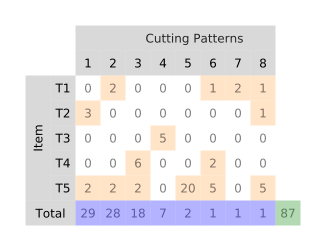

In [1]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Printf # For formatted printing

# Utility functions for plotting the 1D cut solution
include("utils/1dcut_utils.jl")

# Items data
l = [45, 30, 20, 15, 5]     # Length of each item type
d = [60, 88, 35, 110, 200]  # Demand for each part type
n = length(d)               # Number of item types

# Panels data
L = 100                     # Length of each panel
m = 100                     # Total of panels available

# Auxiliary variables to simplify notation
I = 1:n # Range for item types
P = 1:m # Range for panels

# Create the model
model = JuMP.Model(HiGHS.Optimizer)

# Silent mode (solver output is not printed)
JuMP.set_silent(model)

# Variables: number of pieces of item i cut in panel p
@variable(model, x[i in I, p in P] >= 0, Int)

# Variables: binary variable indicating if panel p is used 
@variable(model, y[p in P], Bin)

# Objective: minimize the number of panels used
@objective(model, Min, sum(y[p] for p in P))

# Demand satisfaction 
@constraint(model, [i in I], sum(x[i,p] for p in P) >= d[i])

# Panel length capacity
@constraint(model, [p in P], sum(l[i] * x[i,p] for i in I) <= L * y[p])

# Solve the model
JuMP.optimize!(model)

# Print solution
println("Number of panels used: ", JuMP.objective_value(model), " / $m")

# Extract solution
y_opt = JuMP.value.(y)
x_opt = ceil.(Int64,JuMP.value.(x))

# Find and count each unique patterns
unique_patterns_total = Dict{Vector{Int}, Int}()
for p in P
    if y_opt[p] > 0.5 # Only consider used rolls
        pattern = collect(x_opt[:, p])
        if haskey(unique_patterns_total, pattern)
            unique_patterns_total[pattern] += 1
        else
            unique_patterns_total[pattern] = 1
        end
    end
end

# Sort the unique patterns by their counts in descending order
unique_patterns_total = sort(collect(unique_patterns_total), by = x -> x[2], rev=true)

# Print the unique patterns and their counts
println("\nCutting patterns:")
println("="^28)
@printf("%-20s | %-9s\n", "Pattern (Qty Items)", "Total")
println("-"^28)
for (pattern, count) in unique_patterns_total
    @printf("%-20s | %.0f\n", pattern, count)
end

# Print the production summary
println("\nProduction summary:")
println("="^43)
@printf("%-4s | %-5s | %-8s | %-8s\n", "Type", "Demand", "Production", "Overproduction")
println("-"^43)
for i in I
    produced = sum(x_opt[i, p] for p in P)
    @printf("T%-3d | %-6d | %-10d | %-8d\n", i, d[i], produced, produced - d[i])
end

# Plot the cutting patterns
plot_solution(unique_patterns_total)

<table>
  <tr>
    <td>Chapter</td>
    <td>6 - Column Generation</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>6.2.3.1 - Solving CG for 1D-CSP in Julia</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

Initiating Column Generation...
Iteration 1: LP objective = 87.76 | Reduced Cost = -0.0769
Iteration 2: LP objective = 87.07 | Reduced Cost = -0.0417
Iteration 3: LP objective = 86.90 | Reduced Cost = 0.0000
Column Generation complete: no improving column found.

Cutting patterns:
Pattern (Qty Items)  | Total    
----------------------------
[2, 0, 0, 0, 2]      | 30
[0, 2, 0, 1, 5]      | 20
[0, 3, 0, 0, 2]      | 16
[0, 0, 2, 4, 0]      | 15
[0, 0, 0, 6, 2]      | 5
[0, 0, 5, 0, 0]      | 1

Production summary:
Type | Demand | Production | Overproduction
-------------------------------------------
T1   | 60     | 60         | 0       
T2   | 88     | 88         | 0       
T3   | 35     | 35         | 0       
T4   | 110    | 110        | 0       
T5   | 200    | 202        | 2       


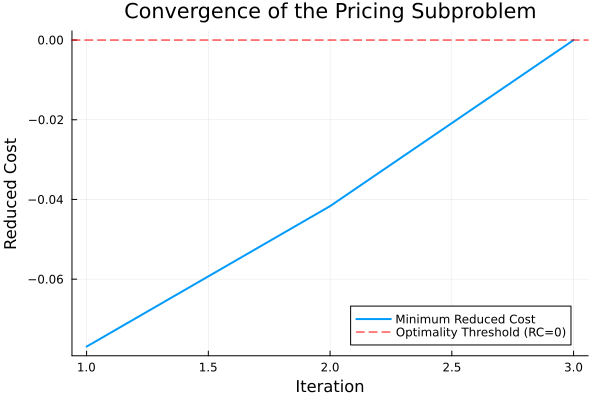

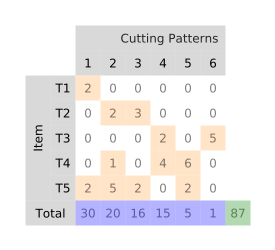

In [2]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Random # For random number generation
using Printf # For formatted printing

# Include utility functions for drawing solutions
include("utils/cg_1dcsp_utils.jl")

# Instance data structure
struct Instance
    L::Int               # Length of the panel
    lengths::Vector{Int} # Lengths of the items
    demands::Vector{Int} # Demands for each item
    n::Int               # Number of item types
    Instance(L, l, d) = new(L, l, d, length(l)) # Contructor
end

# Function to display the final solution
function report_solution(instance::Instance, columns, solution)
    # Columns sorted by quantity produced in descending order
    sorted_patterns = sortperm(collect(solution), rev=true)
    # Extract the amount cutting patterns
    println("\nCutting patterns:")
    println("="^28)
    @printf("%-20s | %-9s\n", "Pattern (Qty Items)", "Total")
    println("-"^28)
    produced = zeros(Int, instance.n)
    for p in sorted_patterns
        val = solution[p]
        if val > 0
            @printf("%-20s | %.0f\n", string(columns[p]), val)
            produced .+= columns[p] .* round(Int, val)
        end
    end
    # Print the production summary
    println("\nProduction summary:")
    println("="^43)
    @printf("%-4s | %-5s | %-8s | %-8s\n", "Type", "Demand", "Production", "Overproduction")
    println("-"^43)
    for i in 1:instance.n
        @printf("T%-3d | %-6d | %-10d | %-8d\n", i, instance.demands[i], produced[i], produced[i] - instance.demands[i])
    end
end

# Function to create initial columns (cutting patterns)
function create_initial_columns(instance::Instance, initial_columns)
    # Basic patterns (one item type by panel)
    columns = [ [i == j ? floor(Int, instance.L / instance.lengths[i]) : 0 for i in 1:instance.n] for j in 1:instance.n ]
    # Add random cutting patterns
    for _ in 1:initial_columns
        new_column = zeros(Int, instance.n)
        # Loop to ensure we don't create a pattern with zero items
        while iszero(new_column)
            # Start with a full panel length
            new_column_length = instance.L
            # Randomly shuffle to create diverse patterns
            for i in shuffle(1:instance.n)
                # Select a random quantity that fits
                qty = rand(0:floor(Int, new_column_length / instance.lengths[i]))
                new_column[i] = qty
                # Update the remaining length of the column
                new_column_length -= qty * instance.lengths[i]
            end
        end
        push!(columns, new_column)
    end
    # Ensure columns are unique
    return unique(columns)
end

# Function to solve the master problem (RMP)
function solve_master_problem(instance::Instance, columns; integer=false)
    # Range of items and patterns
    I = 1:instance.n
    C = 1:length(columns)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Create the decision variables
    if integer
        @variable(model, y[c in C] >= 0, Int)
    else
        @variable(model, y[c in C] >= 0)
    end
    # Minimize the total number of panels used
    @objective(model, Min, sum(y[c] for c in C))
    # For each item i, produce at least the required demand
    @constraint(model, demand_constraints[i in I], sum(columns[c][i] * y[c] for c in C) >= instance.demands[i])
    # Solve the model
    JuMP.optimize!(model)
    # Check the termination status
    if JuMP.termination_status(model) != JuMP.OPTIMAL
        error("RMP did not solve to optimality.")
    end
    # Return results
    if integer
        # Return integer solution (no duals for integer problems)
        return nothing, round.(Int, JuMP.value.(y))
    else
        # Return dual prices and linear programming solution
        return JuMP.dual.(demand_constraints), JuMP.objective_value(model)
    end
end

# Function to solve the pricing subproblem (knapsack problem)
function solve_subproblem(instance::Instance, π)
    # Range of items
    I = 1:instance.n
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Create the decision variables
    @variable(model, x[i in I] >= 0, Int)
    # Maximize the total "value" of the pattern
    @objective(model, Max, sum(π[i] * x[i] for i in I))
    # The number of items of type i cannot exceed the panel length
    @constraint(model, sum(instance.lengths[i] * x[i] for i in I) <= instance.L)
    # Solve the model
    JuMP.optimize!(model)
    # Check the termination status    
    if JuMP.termination_status(model) != JuMP.OPTIMAL
        error("Pricing subproblem was not solved to optimality.")
    end
    # Calculate the reduced cost
    reduced_cost = 1 - JuMP.objective_value(model)
    # Return the reduced cost and the new column
    return reduced_cost, round.(Int, value.(x))
end

# Main function to execute the column generation process
function solve_cg_1dcsp(instance::Instance; initial_columns = 20, iteration_max=100, tolerance=-1e-6)
    # 1. Create initial columns
    columns = create_initial_columns(instance, initial_columns)
    # Reduced cost history for plotting
    reduced_cost_history = Float64[]
    println("Initiating Column Generation...")
    # Main column generation loop
    for iteration in 1:iteration_max
        # 2. Solve the Restricted Master Problem
        π, lp_objective = solve_master_problem(instance, columns)
        # 3. Solve the Pricing Subproblem
        reduced_cost, new_column = solve_subproblem(instance, π)
        # Store reduced cost history
        push!(reduced_cost_history, reduced_cost)
        # Print iteration details
        @printf("Iteration %d: LP objective = %.2f | Reduced Cost = %.4f\n", iteration, lp_objective, reduced_cost)
        # 4. Check if we found a new column
        if reduced_cost < tolerance
            push!(columns, new_column)
        else
            println("Column Generation complete: no improving column found.")
            break
        end
    end
    # 5. Solve the final integer master problem
    _, ip_solution = solve_master_problem(instance, columns, integer=true)
    # Report the final solution
    report_solution(instance, columns, ip_solution)
    # Plot the reduced cost history
    plot_reduced_costs(reduced_cost_history)
    # Plot the final solution
    plot_solution(columns, ip_solution)
end

# Set the random seed for reproducibility
Random.seed!(42)
# Create an instance of the cutting stock problem and solve it
instance = Instance(100, [45, 30, 20, 15, 5], [60, 88, 35, 110, 200])
# Call the main function to solve the problem
solve_cg_1dcsp(instance, initial_columns=20, iteration_max=100, tolerance=-1e-6)

<table>
  <tr>
    <td>Chapter</td>
    <td>6 - Column Generation</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>6.3.2 - Solving CG for the PMP in Julia</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

Initiating Column Generation...
Iteration 100: LP objective = 5239.21 | Reduced Cost = -254.896396
Iteration 200: LP objective = 4774.60 | Reduced Cost = -290.644111
Iteration 300: LP objective = 4774.60 | Reduced Cost = -68.233999
Iteration 400: LP objective = 4774.60 | Reduced Cost = -126.648442
Iteration 500: LP objective = 4774.60 | Reduced Cost = -41.129886
Iteration 600: LP objective = 4774.60 | Reduced Cost = -58.985283
Iteration 700: LP objective = 4774.60 | Reduced Cost = -15.618303
Column Generation complete: no improving column found.

--- FINAL P-MEDIAN SOLUTION ---
Selected facilities (p=3): [26, 8, 18]
Objective value: 4774.5971343036135 meters


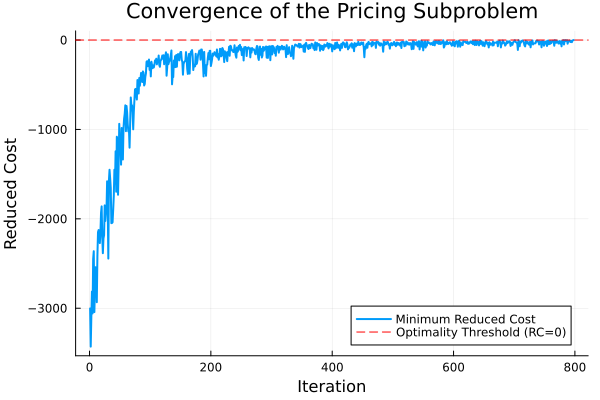

Python: <folium.folium.Map object at 0x7fe142feacf0>

In [3]:
using JuMP       # Modeling language
using HiGHS      # Solver
using CSV        # for reading CSV files
using Distances  # for distance calculations
using Random     # for random number generation
using Printf     # For formatted printing

# Include utility functions for plotting solutions
include("utils/cg_pmp_utils.jl")

# Data structure to hold problem data
struct Instance
    p::Int64                         # Number of medians to select
    coordinates::Matrix{Float64}     # Coordinates of the clients
    distance_matrix::Matrix{Float64} # Distance matrix between clients
    n::Int64                         # Number of clients
    # Constructor
    Instance(p, coordinates, distance_matrix) = new(p, coordinates, distance_matrix, size(coordinates, 1))
end

# Define a structure to hold column information
struct Column
    cost::Float64   # Cost of the column (sum of distances)
    median::Int64   # Index of the median (facility) in this column
    client_assignments::BitVector 
end

# Function to read coordinates and compute Haversine distance matrix
function read_data(file_path, p)
    # Read the CSV file
    coordinates = CSV.read(file_path, CSV.Tables.matrix, header=false)
    # Compute Haversine distance matrix
    distance_matrix = Distances.pairwise(Distances.Haversine(), coordinates, dims=1)
    return Instance(p, coordinates, distance_matrix)
end

# Function to display the final solution
function report_solution(instance::Instance, columns, solution)
    # Extract selected columns based on integer solution
    selected_columns = findall(collect(solution) .> 0.5) 

    # Display the final solution
    println("\n--- FINAL P-MEDIAN SOLUTION ---")
    println("Selected facilities (p=$(instance.p)): ", [columns[c].median for c in selected_columns])
    println("Objective value: ", sum(columns[c].cost for c in selected_columns), " meters")
end

# Function to create initial columns (clusters)
function create_initial_columns(instance::Instance, initial_columns)
    columns = Column[]
    for _ in 1:initial_columns
        # Ensure we don't get an empty cluster
        client_assignments = falses(instance.n)
        while count(client_assignments) == 0
            client_assignments .= rand(Bool, instance.n)
        end
        # Get indices of assigned clients
        assigned_indices = findall(client_assignments)
        # Calculate sum of distances between clients and median
        costs = [sum(instance.distance_matrix[i, assigned_indices]) for i in assigned_indices]
        # Find the point with the minimum cost to be the median
        minimum_cost, idx = findmin(costs)
        median = assigned_indices[idx]
        push!(columns, Column(minimum_cost, median, client_assignments))
    end
    return columns
end

# Function to solve the master problem (RMP)
function solve_master_problem(instance::Instance, columns; integer=false)
    # Range of items and patterns
    I = 1:instance.n
    C = 1:length(columns)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Create the decision variables
    if integer
        @variable(model, y[c in C] >= 0, Bin)
    else
        @variable(model, y[c in C] >= 0)
    end
    # Minimize the total cost of selected columns
    @objective(model, Min, sum(y[c] * columns[c].cost for c in C))
    if integer
        # For integer solutions, we want exactly one column to serve each client
        @constraint(model, coverage_constraints[i in I], sum(columns[c].client_assignments[i] * y[c] for c in C) == 1)
    else
        # For LP relaxation, we allow at least one column to serve each client
        @constraint(model, coverage_constraints[i in I], sum(columns[c].client_assignments[i] * y[c] for c in C) >= 1)
    end
    # Exactly 'p' columns must be chosen
    @constraint(model, p_facilities_constraints, sum(y) == instance.p)
    # Solve the model
    JuMP.optimize!(model)
    # Check the termination status
    if JuMP.termination_status(model) != JuMP.OPTIMAL
        error("RMP did not solve to optimality.")
    end
    # Return results
    if integer
        return nothing, nothing, JuMP.value.(y)
    else
        return JuMP.dual.(coverage_constraints), JuMP.dual(p_facilities_constraints), JuMP.objective_value(model)
    end
end

# Function to solve the pricing subproblem (heuristic)
function solve_subproblem(instance::Instance, π, σ)
    I = J = 1:instance.n
    best_reduced_cost = Inf
    best_column = nothing
    # Enumerate all potential medians j
    for j in J
        client_assignments = falses(instance.n)
        cost = 0.0
        rc = -σ
        # Assign the median, update reduced cost
        client_assignments[j] = true
        rc -= π[j]
        # Greedily assign client i if it reduces the reduced cost
        for i in I
            if i != j
                marginal = instance.distance_matrix[i, j] - π[i]
                if marginal < 0
                    client_assignments[i] = true
                    cost += instance.distance_matrix[i, j]
                    rc += marginal
                end
            end
        end
        # Track the column with the most negative reduced cost
        if rc < best_reduced_cost
            best_reduced_cost = rc
            best_column = Column(cost, j, client_assignments)
        end
    end
    return best_reduced_cost, best_column
end

# Main function to execute the column generation process
function solve_cg_pmp(instance::Instance; initial_columns = 20, iteration_max=100, tolerance=-1e-6)
    # 1. Create initial columns
    columns = create_initial_columns(instance, initial_columns)
    # Reduced cost history for plotting
    reduced_cost_history = Float64[]
    println("Initiating Column Generation...")
    # Main column generation loop
    for iteration in 1:iteration_max
        # 2. Solve the Restricted Master Problem
        π, σ, lp_objective = solve_master_problem(instance, columns)
        # 3. Solve the Pricing Subproblem
        reduced_cost, new_column = solve_subproblem(instance, π, σ)
        # Store reduced cost history
        push!(reduced_cost_history, reduced_cost)
        # Print iteration details
        if iteration % 100 == 0
            @printf("Iteration %d: LP objective = %.2f | Reduced Cost = %.6f\n", iteration, lp_objective, reduced_cost)
        end
        # 4. Check if we found a new column
        if reduced_cost < tolerance
            push!(columns, new_column)
        else
            println("Column Generation complete: no improving column found.")
            break
        end
    end

    # 5. Solve the final integer master problem
    _, _, ip_solution = solve_master_problem(instance, columns, integer=true)
    
    # Report the final solution
    report_solution(instance, columns, ip_solution)

    # Plot the reduced cost history
    plot_reduced_costs(reduced_cost_history)

    # Plot a map of the final solution
    plot_solution(instance, columns, ip_solution)
end

# Set the random seed for reproducibility
Random.seed!(42)
# Load the instance data
instance = read_data("data/cg_pmp_coordinates.csv", 3)
# Call the main function to solve the problem
solve_cg_pmp(instance, initial_columns = 500, iteration_max=1000, tolerance=-1e-6)